# E-Commerce Big Data Mining for Customer Intelligence

**Dataset:** Instacart Market Basket data (about 3.4 million orders and 32 million purchased-product rows).
**Techniques:** K-Means customer segmentation, FP-Growth frequent itemsets, association rules for product recommendation.

**Key method decisions (and why)**
- Customer features are built from **prior orders only**, so `total_orders` and `total_products` describe the same set of orders.
- Skewed features are **log-transformed** before scaling so a few extreme customers do not dominate K-Means.
- The number of clusters is checked with both the **elbow method and the silhouette score**.
- Segment names are assigned **automatically from each cluster's profile**, not from cluster numbers.
- **Bananas are excluded from rule mining.** They appear in roughly a third of all orders, so nearly every rule would just say "... -> banana".
- Rules are mined on a **random sample of 1,000,000 orders** with support measured against all sampled orders.

**Scalability note:** the pipeline runs on a single machine with pandas, scikit-learn and mlxtend. For data that no longer fits in memory, the same steps map directly to PySpark (`KMeans` and `FPGrowth` in MLlib).

## **Step 1: Import Library**

In [1]:
import os
import pandas as pd
import numpy as np

# Folder where all results for the Streamlit app are saved
os.makedirs("../processed_data", exist_ok=True)

## **Step 2: Load orders.csv**

In [2]:
# Load orders.csv
orders = pd.read_csv("../Dataset/orders.csv")

# Show first 5 rows
print(orders.head(5))

# Show schema
print(orders.dtypes)

# Count total orders
print("Total orders:", len(orders))

   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object
Total orders: 3421083


In [3]:
# The customer features must be built ONLY from "prior" orders.
# orders.csv also contains each customer's last order (train/test set),
# but the products of that order are NOT in order_products__prior.csv.
# Counting it would make total_orders inconsistent with total_products.
print(orders["eval_set"].value_counts())

orders_prior = orders[orders["eval_set"] == "prior"].copy()

print("\nPrior orders:", len(orders_prior))

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Prior orders: 3214874


## **Step 3: Load order_products__prior.csv**

In [4]:
# Load order_products__prior.csv
order_products = pd.read_csv("../Dataset/order_products__prior.csv")

# Show first 5 records
print(order_products.head(5))

# Show schema
print(order_products.dtypes)

# Count total records
print("Total product-order records:", len(order_products))

   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object
Total product-order records: 32434489


## **Step 4: Load products.csv**

In [5]:
# Load products.csv

products = pd.read_csv("../Dataset/products.csv")

# Show first 5 products
print(products.head(5))

# Show schema
print(products.dtypes)

# Count products
print("Total products:", len(products))

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
product_id        int64
product_name     object
aisle_id          int64
department_id     int64
dtype: object
Total products: 49688


## **Step 5: Join Orders + Products**

In [6]:
# Join orders with order_products

customer_products = pd.merge(
    orders,
    order_products,
    on="order_id",
    how="inner"
)

# Show the result
print(customer_products.head(5))

   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2539329        1    prior             1          2                  8   
2   2539329        1    prior             1          2                  8   
3   2539329        1    prior             1          2                  8   
4   2539329        1    prior             1          2                  8   

   days_since_prior_order  product_id  add_to_cart_order  reordered  
0                     NaN         196                  1          0  
1                     NaN       14084                  2          0  
2                     NaN       12427                  3          0  
3                     NaN       26088                  4          0  
4                     NaN       26405                  5          0  


In [7]:
print("Columns:", customer_products.columns.tolist())

Columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_id', 'add_to_cart_order', 'reordered']


In [8]:
# Select only the columns we need
customer_products = customer_products[[
    "user_id",
    "order_id",
    "product_id",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "reordered"
]]

print(customer_products.head(5))

   user_id  order_id  product_id  order_number  order_dow  order_hour_of_day  \
0        1   2539329         196             1          2                  8   
1        1   2539329       14084             1          2                  8   
2        1   2539329       12427             1          2                  8   
3        1   2539329       26088             1          2                  8   
4        1   2539329       26405             1          2                  8   

   reordered  
0          0  
1          0  
2          0  
3          0  
4          0  


## **Step 6: Add Product Names**

In [9]:
customer_products = pd.merge(
    customer_products,
    products,
    on="product_id",
    how="left"
)

print(customer_products.head(5))

   user_id  order_id  product_id  order_number  order_dow  order_hour_of_day  \
0        1   2539329         196             1          2                  8   
1        1   2539329       14084             1          2                  8   
2        1   2539329       12427             1          2                  8   
3        1   2539329       26088             1          2                  8   
4        1   2539329       26405             1          2                  8   

   reordered                             product_name  aisle_id  department_id  
0          0                                     Soda        77              7  
1          0  Organic Unsweetened Vanilla Almond Milk        91             16  
2          0                      Original Beef Jerky        23             19  
3          0               Aged White Cheddar Popcorn        23             19  
4          0         XL Pick-A-Size Paper Towel Rolls        54             17  


In [10]:
# Select only the columns we need

customer_products = customer_products[[
    "user_id",
    "order_id",
    "product_id",
    "product_name",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "reordered"
]]

print(customer_products.head(5))

   user_id  order_id  product_id                             product_name  \
0        1   2539329         196                                     Soda   
1        1   2539329       14084  Organic Unsweetened Vanilla Almond Milk   
2        1   2539329       12427                      Original Beef Jerky   
3        1   2539329       26088               Aged White Cheddar Popcorn   
4        1   2539329       26405         XL Pick-A-Size Paper Towel Rolls   

   order_number  order_dow  order_hour_of_day  reordered  
0             1          2                  8          0  
1             1          2                  8          0  
2             1          2                  8          0  
3             1          2                  8          0  
4             1          2                  8          0  


## **Step 7: Missing Value Analysis**

In [11]:
# Check missing values in each column
missing_values = customer_products.isnull().sum()

print(missing_values)

user_id              0
order_id             0
product_id           0
product_name         0
order_number         0
order_dow            0
order_hour_of_day    0
reordered            0
dtype: int64


## **Step 8: Check Duplicates Records**

In [12]:
# Count total records
total_records = len(customer_products)

print("Total records:", total_records)

Total records: 32434489


In [13]:
# Count unique records
unique_records = len(customer_products.drop_duplicates())

print("Unique records:", unique_records)

Unique records: 32434489


In [14]:
# Duplicate records
print("Duplicate records:", total_records - unique_records)

Duplicate records: 0


## **Step 9: Check Invalid Values**

In [15]:
# Check order_dow (day of week) should be between 0 and 6.
# NOTE: the dataset does not document which number is which day (see Step 30).
print(np.sort(orders["order_dow"].unique()))

[0 1 2 3 4 5 6]


In [16]:
# Check order_hour_of_day should be between 0 and 23
print(np.sort(orders["order_hour_of_day"].unique()))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [17]:
# check reordered column should be either 0 or 1
print(order_products["reordered"].unique())

[1 0]


In [18]:
# Check order_number
print(np.sort(orders["order_number"].unique())[:10])

[ 1  2  3  4  5  6  7  8  9 10]


## **Step 10: Create Customer Features**

### Feature 1: Number of Orders
- How many orders did each customer make?

In [19]:
# Count total orders placed by each customer
customer_orders = orders_prior.groupby("user_id").agg(
    {"order_id": "count"}
).reset_index()

# Rename the column to "total_orders"
customer_orders = customer_orders.rename(
    columns={"order_id": "total_orders"}
)

print(customer_orders.head(10))

   user_id  total_orders
0        1            10
1        2            14
2        3            12
3        4             5
4        5             4
5        6             3
6        7            20
7        8             3
8        9             3
9       10             5


### Feature 2: Total Products Purchased
- How many products did each customer purchase in total?

In [20]:
# Count total products purchased by each customer
customer_products_count = customer_products.groupby("user_id").agg(
    {"product_id": "count"}
).reset_index()

# Rename the column to "total_products"
customer_products_count = customer_products_count.rename(
    columns={"product_id": "total_products"}
)

print(customer_products_count.head(10))

   user_id  total_products
0        1              59
1        2             195
2        3              88
3        4              18
4        5              37
5        6              14
6        7             206
7        8              49
8        9              76
9       10             143


### Feature 3: Average Products Per Order
- On average, how many products does a customer purchase in one orde

In [21]:
# Join customer_orders and customer_products_count to create a new DataFrame with customer features
customer_features = pd.merge(
    customer_orders,
    customer_products_count,
    on="user_id",
    how="inner"
)

# calculate average products per order for each customer
customer_features["avg_products_per_order"] = (
    customer_features["total_products"] / customer_features["total_orders"]
)

print(customer_features.head(10))

   user_id  total_orders  total_products  avg_products_per_order
0        1            10              59                5.900000
1        2            14             195               13.928571
2        3            12              88                7.333333
3        4             5              18                3.600000
4        5             4              37                9.250000
5        6             3              14                4.666667
6        7            20             206               10.300000
7        8             3              49               16.333333
8        9             3              76               25.333333
9       10             5             143               28.600000


### Feature 4: Reorder Rate
- What percentage of a customer's purchased products were reordered?

In [22]:
# Calculate Reorder Rate = Reordered Products / Total Products
customer_reorder = customer_products.groupby("user_id").agg(
    reorder_rate=("reordered", "mean")
).reset_index()

print(customer_reorder.head(10))

   user_id  reorder_rate
0        1      0.694915
1        2      0.476923
2        3      0.625000
3        4      0.055556
4        5      0.378378
5        6      0.142857
6        7      0.669903
7        8      0.265306
8        9      0.236842
9       10      0.342657


In [23]:
# join customer_features with customer_reorder to add reorder_rate to the features
customer_features = pd.merge(
    customer_features,
    customer_reorder,
    on="user_id",
    how="inner"
)

print(customer_features.head(10))

   user_id  total_orders  total_products  avg_products_per_order  reorder_rate
0        1            10              59                5.900000      0.694915
1        2            14             195               13.928571      0.476923
2        3            12              88                7.333333      0.625000
3        4             5              18                3.600000      0.055556
4        5             4              37                9.250000      0.378378
5        6             3              14                4.666667      0.142857
6        7            20             206               10.300000      0.669903
7        8             3              49               16.333333      0.265306
8        9             3              76               25.333333      0.236842
9       10             5             143               28.600000      0.342657


### Feature 5: Average Days Between Orders
- how frequently a customer returns to shop.

> Note: `days_since_prior_order` is capped at 30 days in the source data, so averages are slightly underestimated for infrequent customers.

In [24]:
# Calculate average days between orders for each customer
customer_days = orders_prior.groupby("user_id").agg(
    avg_days_between_orders=("days_since_prior_order", "mean")
).reset_index()

print(customer_days.head(10))

   user_id  avg_days_between_orders
0        1                19.555556
1        2                15.230769
2        3                12.090909
3        4                13.750000
4        5                13.333333
5        6                 9.000000
6        7                10.684211
7        8                30.000000
8        9                18.000000
9       10                19.750000


In [25]:
# join customer_features with customer_days to add avg_days_between_orders to the features
customer_features = pd.merge(
    customer_features,
    customer_days,
    on="user_id",
    how="inner"
)

print(customer_features.head(10))

   user_id  total_orders  total_products  avg_products_per_order  \
0        1            10              59                5.900000   
1        2            14             195               13.928571   
2        3            12              88                7.333333   
3        4             5              18                3.600000   
4        5             4              37                9.250000   
5        6             3              14                4.666667   
6        7            20             206               10.300000   
7        8             3              49               16.333333   
8        9             3              76               25.333333   
9       10             5             143               28.600000   

   reorder_rate  avg_days_between_orders  
0      0.694915                19.555556  
1      0.476923                15.230769  
2      0.625000                12.090909  
3      0.055556                13.750000  
4      0.378378                13.33

In [26]:
# Check the final customer_features DataFrame
print("Total customers:", len(customer_features))
print("Total features:", len(customer_features.columns))

Total customers: 206209
Total features: 6


In [27]:
# Sanity check: every prior order should be counted exactly once
print("Orders counted in features:", customer_features["total_orders"].sum())
print("Prior orders in orders.csv:", len(orders_prior))

Orders counted in features: 3214874
Prior orders in orders.csv: 3214874


In [28]:
print(customer_features.dtypes)

user_id                      int64
total_orders                 int64
total_products               int64
avg_products_per_order     float64
reorder_rate               float64
avg_days_between_orders    float64
dtype: object


## **Step 11: Prepare Features for K-Means**

Order counts and basket sizes are strongly right-skewed (a few very heavy shoppers). Without a transformation, those customers dominate the distance calculation. We apply `log1p` to the skewed features and check the correlation between features.

In [29]:
features = [
    "total_orders",
    "total_products",
    "avg_products_per_order",
    "reorder_rate",
    "avg_days_between_orders"
]

skewed_features = ["total_orders", "total_products", "avg_products_per_order"]

# Safety: K-Means cannot handle missing values
print("Missing values:\n", customer_features[features].isnull().sum())
customer_features["avg_days_between_orders"] = customer_features[
    "avg_days_between_orders"
].fillna(customer_features["avg_days_between_orders"].median())

print("\nSkewness BEFORE log transform:")
print(customer_features[features].skew().round(2))

# Log-transform the skewed features (only for clustering; the original
# values are kept in customer_features for reporting)
customer_model = customer_features[features].copy()

for col in skewed_features:
    customer_model[col] = np.log1p(customer_model[col])

print("\nSkewness AFTER log transform:")
print(customer_model.skew().round(2))

print("\nFeature correlation (original values):")
print(customer_features[features].corr().round(2))

Missing values:
 total_orders               0
total_products             0
avg_products_per_order     0
reorder_rate               0
avg_days_between_orders    0
dtype: int64

Skewness BEFORE log transform:
total_orders               2.40
total_products             3.18
avg_products_per_order     1.23
reorder_rate               0.03
avg_days_between_orders    0.34
dtype: float64

Skewness AFTER log transform:
total_orders               0.56
total_products             0.05
avg_products_per_order    -0.33
reorder_rate               0.03
avg_days_between_orders    0.34
dtype: float64

Feature correlation (original values):
                         total_orders  total_products  avg_products_per_order  \
total_orders                     1.00            0.81                    0.02   
total_products                   0.81            1.00                    0.42   
avg_products_per_order           0.02            0.42                    1.00   
reorder_rate                     0.64           

## **Step 12: Standardize the Features**

In [30]:
# Scale the (log-transformed) features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(
    with_mean=True,
    with_std=True
)

scaled_features = scaler.fit_transform(customer_model[features])

print("Scaled matrix shape:", scaled_features.shape)
print(scaled_features[:5].round(3))

Scaled matrix shape: (206209, 5)
[[-0.07  -0.336 -0.578  1.238  0.612]
 [ 0.317  0.733  0.821  0.211  0.003]
 [ 0.138  0.02  -0.236  0.909 -0.439]
 [-0.827 -1.375 -1.313 -1.776 -0.205]
 [-1.055 -0.749  0.139 -0.254 -0.264]]


## **Step 13: Find the Best Number of Clusters**

K = 2 | Inertia = 610657.9 | Silhouette = 0.3473
K = 3 | Inertia = 493475.4 | Silhouette = 0.2735
K = 4 | Inertia = 423356.7 | Silhouette = 0.2409
K = 5 | Inertia = 373336.0 | Silhouette = 0.238
K = 6 | Inertia = 326085.6 | Silhouette = 0.2491
K = 7 | Inertia = 301851.8 | Silhouette = 0.2339
K = 8 | Inertia = 281960.4 | Silhouette = 0.225


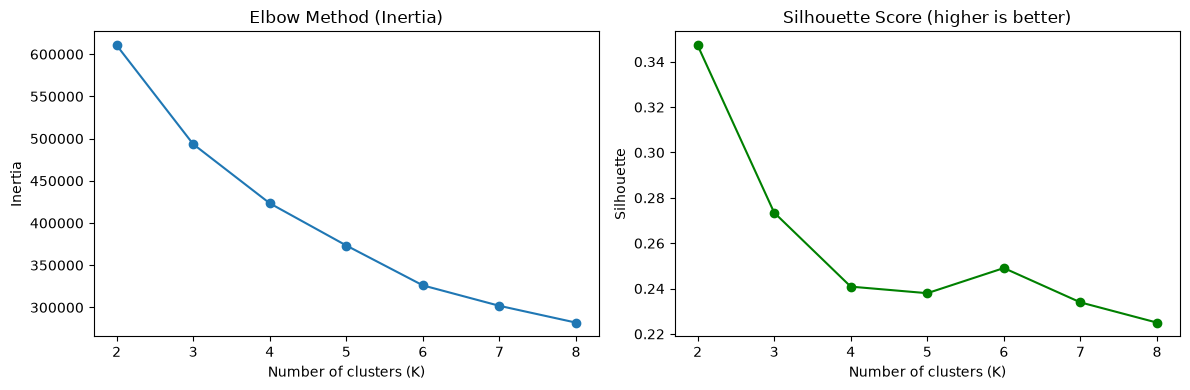

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_RANGE = range(2, 9)

inertia_values = []
silhouette_values = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)

    inertia_values.append(km.inertia_)

    # Silhouette on a random sample (full data would be too slow)
    sil = silhouette_score(
        scaled_features,
        labels,
        sample_size=min(20000, len(scaled_features)),
        random_state=42
    )
    silhouette_values.append(sil)

    print("K =", k, "| Inertia =", round(km.inertia_, 1), "| Silhouette =", round(sil, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), inertia_values, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_RANGE), silhouette_values, marker="o", color="green")
axes[1].set_title("Silhouette Score (higher is better)")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

**How K is chosen:** the inertia curve falls smoothly without a sharp elbow, so we use it together with the silhouette scores above and the business need for interpretable groups. We use **K = 5**, which gives five distinct, explainable customer types. Compare the silhouette of K = 5 with its neighbours in the printout above and mention that trade-off in your report.

## **Step 14: Create the Customer Segments**

In [32]:
# K = 5 clusters (see the discussion under Step 13).
# The automatic naming in Step 16 is written for exactly 5 clusters.
K = 5

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = kmeans.fit_predict(scaled_features)

customer_features.head(10)

,user_id,total_orders,total_products,avg_products_per_order,reorder_rate,avg_days_between_orders,cluster
0,1,10,59,5.900000,0.694915,19.555556,4
1,2,14,195,13.928571,0.476923,15.230769,0
2,3,12,88,7.333333,0.625000,12.090909,4
3,4,5,18,3.600000,0.055556,13.750000,1
4,5,4,37,9.250000,0.378378,13.333333,3
5,6,3,14,4.666667,0.142857,9.000000,1
6,7,20,206,10.300000,0.669903,10.684211,2
7,8,3,49,16.333333,0.265306,30.000000,3
8,9,3,76,25.333333,0.236842,18.000000,3
9,10,5,143,28.600000,0.342657,19.750000,0


In [33]:
print(customer_features["cluster"].value_counts().sort_index())

cluster
0    45877
1    29599
2    38773
3    54872
4    37088
Name: count, dtype: int64


## **Step 15: Analyze the Customer Segments**
- What kind of customers are present in each cluster?

In [34]:
# Summarize the clusters by calculating the mean of each feature for each cluster
cluster_summary = customer_features.groupby("cluster")[
    [
        "total_orders",
        "total_products",
        "avg_products_per_order",
        "reorder_rate",
        "avg_days_between_orders"
    ]
].mean()

cluster_summary.round(2)

,total_orders,total_products,avg_products_per_order,reorder_rate,avg_days_between_orders
cluster,,,,,
0,12.37,173.40,14.72,0.48,14.91
1,5.10,18.26,3.73,0.28,20.83
2,42.54,466.03,11.52,0.69,7.98
3,5.15,55.68,11.35,0.24,19.67
4,15.22,75.89,5.32,0.51,12.05


### Cluster interpretation

Segment names are assigned **automatically** in Step 16 from each cluster's average behaviour, so they stay correct even if the cluster numbers change:

| Segment | Rule used |
| --- | --- |
| **Highly Loyal Customers** | cluster with the highest average `total_orders` |
| **Bulk Basket Customers** | of the rest, highest `avg_products_per_order` |
| **Occasional Customers** | of the rest, longest `avg_days_between_orders` |
| **Frequent Customers** | of the last two, higher `reorder_rate` |
| **Regular Customers** | the last remaining cluster |

Always read the printed summary in Step 16 to confirm the names make sense.

## **Step 16: Add Meaningful Segment Names**

In [35]:
def name_clusters(summary):
    """Give each of the 5 clusters a business name based on its profile."""
    assert len(summary) == 5, "Automatic naming is written for exactly 5 clusters"

    remaining = list(summary.index)
    names = {}

    def take(column, largest=True):
        values = summary.loc[remaining, column]
        chosen = values.idxmax() if largest else values.idxmin()
        remaining.remove(chosen)
        return chosen

    names[take("total_orders")] = "Highly Loyal Customers"
    names[take("avg_products_per_order")] = "Bulk Basket Customers"
    names[take("avg_days_between_orders")] = "Occasional Customers"
    names[take("reorder_rate")] = "Frequent Customers"
    names[remaining[0]] = "Regular Customers"

    return names


cluster_names = name_clusters(cluster_summary)

customer_features["customer_segment"] = customer_features["cluster"].map(cluster_names)

# Check: profile of each named segment
print(cluster_summary.rename(index=cluster_names).round(2))

                        total_orders  total_products  avg_products_per_order  \
cluster                                                                        
Bulk Basket Customers          12.37          173.40                   14.72   
Occasional Customers            5.10           18.26                    3.73   
Highly Loyal Customers         42.54          466.03                   11.52   
Regular Customers               5.15           55.68                   11.35   
Frequent Customers             15.22           75.89                    5.32   

                        reorder_rate  avg_days_between_orders  
cluster                                                        
Bulk Basket Customers           0.48                    14.91  
Occasional Customers            0.28                    20.83  
Highly Loyal Customers          0.69                     7.98  
Regular Customers               0.24                    19.67  
Frequent Customers              0.51                   

In [36]:
customer_features["customer_segment"].value_counts()

customer_segment
Regular Customers         54872
Bulk Basket Customers     45877
Highly Loyal Customers    38773
Frequent Customers        37088
Occasional Customers      29599
Name: count, dtype: int64

## **Step 17: Check the most frequently purchased products**

In [37]:
# Analyze the most purchased products by customers
product_counts = customer_products["product_name"].value_counts()

print("Total unique products:", len(product_counts))
print("\nTop 20 most purchased products:")
print(product_counts.head(20))

Total unique products: 49677

Top 20 most purchased products:
product_name
Banana                      472565
Bag of Organic Bananas      379450
Organic Strawberries        264683
Organic Baby Spinach        241921
Organic Hass Avocado        213584
Organic Avocado             176815
Large Lemon                 152657
Strawberries                142951
Limes                       140627
Organic Whole Milk          137905
Organic Raspberries         137057
Organic Yellow Onion        113426
Organic Garlic              109778
Organic Zucchini            104823
Organic Blueberries         100060
Cucumber Kirby               97315
Organic Fuji Apple           89632
Organic Lemon                87746
Apple Honeycrisp Organic     85020
Organic Grape Tomatoes       84255
Name: count, dtype: int64


## **Step 18: Select products for market basket analysis**

Bananas (`Banana`, `Bag of Organic Bananas`) appear in roughly a third of all orders. If they stay in, almost every rule ends in "... -> banana", which is true but useless for recommendations. We treat them as **staples** and exclude them from rule mining, then use the **top 150** remaining products (instead of 100) so more products get recommendations.

In [38]:
STAPLE_PRODUCTS = ["Banana", "Bag of Organic Bananas"]
TOP_N_PRODUCTS = 150
SAMPLE_ORDERS = 1_000_000

# Most purchased products, without the staples
candidate_products = product_counts.drop(labels=STAPLE_PRODUCTS, errors="ignore")

top_products = candidate_products.head(TOP_N_PRODUCTS).index

print("Staples excluded:", STAPLE_PRODUCTS)
print("Number of selected products:", len(top_products))
print("\nTop 10 selected products:")
print(list(top_products[:10]))

Staples excluded: ['Banana', 'Bag of Organic Bananas']
Number of selected products: 150

Top 10 selected products:
['Organic Strawberries', 'Organic Baby Spinach', 'Organic Hass Avocado', 'Organic Avocado', 'Large Lemon', 'Strawberries', 'Limes', 'Organic Whole Milk', 'Organic Raspberries', 'Organic Yellow Onion']


## **Step 19: Sample orders and filter the transaction data**

A random sample of 1,000,000 prior orders keeps memory usage manageable; support, confidence and lift estimated from that many random orders are very close to the full-data values. Orders that contain none of the selected products are **kept as empty baskets**, so support is measured against all orders and is not inflated.

In [39]:
sampled_orders = orders_prior["order_id"].sample(
    n=min(SAMPLE_ORDERS, len(orders_prior)),
    random_state=42
)

market_basket_data = customer_products[
    customer_products["order_id"].isin(sampled_orders)
    & customer_products["product_name"].isin(top_products)
]

print("Sampled orders:", len(sampled_orders))
print("Original transaction rows:", len(customer_products))
print("Filtered transaction rows:", len(market_basket_data))
print("Unique products:", market_basket_data["product_name"].nunique())

Sampled orders: 1000000
Original transaction rows: 32434489
Filtered transaction rows: 2511173
Unique products: 150


## **Step 20: Create the Basket Matrix**

In [40]:
# Basket matrix: one row per sampled order, one column per product
basket = (
    market_basket_data
    .groupby(["order_id", "product_name"])["product_id"]
    .count()
    .unstack(fill_value=0)
    .gt(0)
)

# Add the orders that contain none of the selected products (all False)
basket = basket.reindex(sampled_orders.values, fill_value=False).astype(bool)

print("Basket shape:", basket.shape)
print("Average selected products per order:", round(basket.sum(axis=1).mean(), 2))

Basket shape: (1000000, 150)
Average selected products per order: 2.51


## **Step 21: Run FP-Growth**

In [41]:
from mlxtend.frequent_patterns import fpgrowth

MIN_SUPPORT = 0.005

# max_len=2: we only need "product A -> product B" rules for recommendations
frequent_itemsets = fpgrowth(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=2
)

print("Number of frequent itemsets:", len(frequent_itemsets))

print("\nTop frequent itemsets:")
print(
    frequent_itemsets
    .sort_values("support", ascending=False)
    .head(20)
)

Number of frequent itemsets: 182

Top frequent itemsets:
      support                    itemsets
0    0.082169      (Organic Strawberries)
10   0.075297      (Organic Baby Spinach)
19   0.066512      (Organic Hass Avocado)
46   0.055168           (Organic Avocado)
11   0.047525               (Large Lemon)
14   0.044275              (Strawberries)
24   0.043857                     (Limes)
47   0.043011        (Organic Whole Milk)
21   0.042680       (Organic Raspberries)
1    0.035491      (Organic Yellow Onion)
48   0.034251            (Organic Garlic)
25   0.032886          (Organic Zucchini)
15   0.031314       (Organic Blueberries)
26   0.030292            (Cucumber Kirby)
6    0.027843        (Organic Fuji Apple)
62   0.027339             (Organic Lemon)
121  0.026342  (Apple Honeycrisp Organic)
22   0.026207    (Organic Grape Tomatoes)
27   0.025621       (Seedless Red Grapes)
2    0.025015          (Organic Cucumber)


## **Step 22: Generate Association Rules**

We keep only rules that are actually useful for recommendations:
- **lift >= 1.2**: the products are bought together at least 20% more often than by chance
- **confidence >= 0.10**: at least 10% of orders with product A also contain product B
- single product on each side (A -> B), so each product can be looked up directly in the app

In [42]:
from mlxtend.frequent_patterns import association_rules

MIN_LIFT = 1.2
MIN_CONFIDENCE = 0.10

rules_all = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=MIN_LIFT
)

rules = rules_all[
    (rules_all["confidence"] >= MIN_CONFIDENCE)
    & (rules_all["antecedents"].apply(len) == 1)
    & (rules_all["consequents"].apply(len) == 1)
].copy().reset_index(drop=True)

first_item = lambda s: list(s)[0]

print("Number of association rules:", len(rules))
print("Products that get at least one recommendation:",
      rules["antecedents"].apply(first_item).nunique())

print("\nMost frequently recommended products (check that no single item dominates):")
print(rules["consequents"].apply(first_item).value_counts().head(10))

print("\nTop 20 association rules:")
print(
    rules[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ]
    .sort_values(["lift", "confidence"], ascending=False)
    .head(20)
)

Number of association rules: 45
Products that get at least one recommendation: 15

Most frequently recommended products (check that no single item dominates):
consequents
Organic Strawberries    10
Organic Baby Spinach    10
Organic Hass Avocado     9
Limes                    4
Organic Avocado          3
Large Lemon              2
Organic Raspberries      2
Organic Garlic           2
Organic Cilantro         1
Organic Yellow Onion     1
Name: count, dtype: int64

Top 20 association rules:
               antecedents             consequents   support  confidence  \
31      (Organic Cilantro)                 (Limes)  0.005604    0.256511   
30                 (Limes)      (Organic Cilantro)  0.005604    0.127779   
38        (Organic Garlic)  (Organic Yellow Onion)  0.007067    0.206330   
37  (Organic Yellow Onion)        (Organic Garlic)  0.007067    0.199121   
21                 (Limes)           (Large Lemon)  0.008511    0.194063   
22           (Large Lemon)                 (Limes)

## **Step 23: Sort rules by Lift**

In [43]:
# Sort the rules by lift and confidence in descending order
best_rules = rules.sort_values(
    ["lift", "confidence"],
    ascending=False
)

print("Top 10 rules by lift:")

print(
    best_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

Top 10 rules by lift:
               antecedents             consequents   support  confidence  \
31      (Organic Cilantro)                 (Limes)  0.005604    0.256511   
30                 (Limes)      (Organic Cilantro)  0.005604    0.127779   
38        (Organic Garlic)  (Organic Yellow Onion)  0.007067    0.206330   
37  (Organic Yellow Onion)        (Organic Garlic)  0.007067    0.199121   
21                 (Limes)           (Large Lemon)  0.008511    0.194063   
22           (Large Lemon)                 (Limes)  0.008511    0.179085   
43         (Organic Lemon)  (Organic Hass Avocado)  0.006670    0.243974   
44  (Organic Hass Avocado)         (Organic Lemon)  0.006670    0.100283   
41                 (Limes)        (Organic Garlic)  0.005032    0.114737   
42        (Organic Garlic)                 (Limes)  0.005032    0.146915   

        lift  
31  5.848808  
30  5.848808  
38  5.813579  
37  5.813579  
21  4.083378  
22  4.083378  
43  3.668117  
44  3.668117  
41  3.

## **Step 24: Create a recommendation function**

In [44]:
# Define a function to recommend products based on a given product name
def recommend_products(product_name, top_n=5):

    recommendations = rules[
        rules["antecedents"].apply(
            lambda x: product_name in x
        )
    ]

    recommendations = recommendations.sort_values(
        ["lift", "confidence"],
        ascending=False
    )

    recommendations = recommendations.head(top_n)

    recommendations["recommended_product"] = (
        recommendations["consequents"]
        .apply(lambda x: ", ".join(x))
    )

    return recommendations[
        [
            "recommended_product",
            "confidence",
            "lift"
        ]
    ]

In [45]:
# Try the recommender on the products that have the most rules
example_products = (
    rules["antecedents"].apply(first_item).value_counts().index[:3]
)

for product in example_products:
    print("Recommendations for:", product)
    print(recommend_products(product))
    print()

Recommendations for: Limes
     recommended_product  confidence      lift
30      Organic Cilantro    0.127779  5.848808
21           Large Lemon    0.194063  4.083378
41        Organic Garlic    0.114737  3.349874
26       Organic Avocado    0.159222  2.886130
24  Organic Hass Avocado    0.142440  2.141571

Recommendations for: Organic Yellow Onion
     recommended_product  confidence      lift
37        Organic Garlic    0.199121  5.813579
2   Organic Hass Avocado    0.175256  2.634949
1   Organic Baby Spinach    0.174439  2.316674
0   Organic Strawberries    0.146798  1.786535

Recommendations for: Large Lemon
     recommended_product  confidence      lift
22                 Limes    0.179085  4.083378
9        Organic Avocado    0.159369  2.888790
7   Organic Baby Spinach    0.148090  1.966751
10  Organic Strawberries    0.105313  1.281663



## **Step 25: Product Analysis**

In [46]:
# Analyze the top 20 most purchased products
top_20_products = product_counts.head(20)

print("Top 20 Most Purchased Products:")
print(top_20_products)

Top 20 Most Purchased Products:
product_name
Banana                      472565
Bag of Organic Bananas      379450
Organic Strawberries        264683
Organic Baby Spinach        241921
Organic Hass Avocado        213584
Organic Avocado             176815
Large Lemon                 152657
Strawberries                142951
Limes                       140627
Organic Whole Milk          137905
Organic Raspberries         137057
Organic Yellow Onion        113426
Organic Garlic              109778
Organic Zucchini            104823
Organic Blueberries         100060
Cucumber Kirby               97315
Organic Fuji Apple           89632
Organic Lemon                87746
Apple Honeycrisp Organic     85020
Organic Grape Tomatoes       84255
Name: count, dtype: int64


In [47]:
# Create a DataFrame for the top 20 products with their purchase counts
top_products_df = top_20_products.reset_index()

top_products_df.columns = [
    "product_name",
    "purchase_count"
]

print(top_products_df)

                product_name  purchase_count
0                     Banana          472565
1     Bag of Organic Bananas          379450
2       Organic Strawberries          264683
3       Organic Baby Spinach          241921
4       Organic Hass Avocado          213584
5            Organic Avocado          176815
6                Large Lemon          152657
7               Strawberries          142951
8                      Limes          140627
9         Organic Whole Milk          137905
10       Organic Raspberries          137057
11      Organic Yellow Onion          113426
12            Organic Garlic          109778
13          Organic Zucchini          104823
14       Organic Blueberries          100060
15            Cucumber Kirby           97315
16        Organic Fuji Apple           89632
17             Organic Lemon           87746
18  Apple Honeycrisp Organic           85020
19    Organic Grape Tomatoes           84255


## **Step 26: Visualize the Top 20 Products**

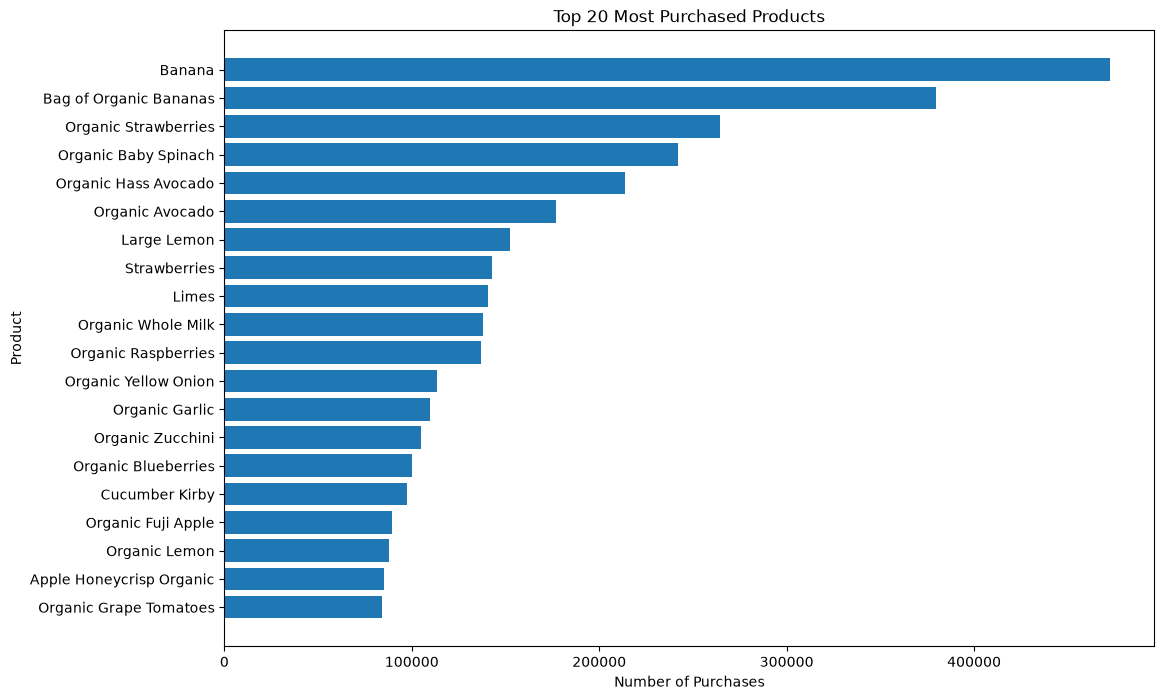

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.barh(
    top_products_df["product_name"],
    top_products_df["purchase_count"]
)

plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.title("Top 20 Most Purchased Products")

plt.gca().invert_yaxis()

plt.show()

## **Step 27: Customer Segment Distribution**

In [49]:
# Summarize the customer segment distribution
segment_counts = (
    customer_features["customer_segment"]
    .value_counts()
)

print("Customer Segment Distribution:")
print(segment_counts)

Customer Segment Distribution:
customer_segment
Regular Customers         54872
Bulk Basket Customers     45877
Highly Loyal Customers    38773
Frequent Customers        37088
Occasional Customers      29599
Name: count, dtype: int64


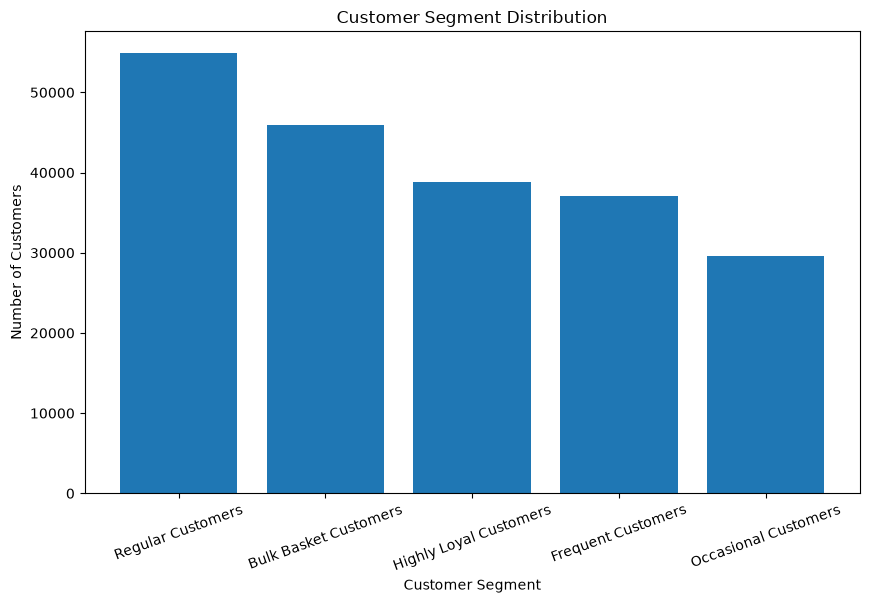

In [50]:
# Visualize the customer segment distribution using a bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution")

plt.xticks(rotation=20)

plt.show()

In [51]:
# Automatic interpretation of the segment distribution
largest = segment_counts.idxmax()
smallest = segment_counts.idxmin()

print(
    f"{largest} form the largest segment ({segment_counts[largest]:,} customers), "
    f"while {smallest} form the smallest ({segment_counts[smallest]:,} customers)."
)

Regular Customers form the largest segment (54,872 customers), while Occasional Customers form the smallest (29,599 customers).


## **Step 28: Visualize the K-Means cluster characteristics**

In [52]:
cluster_summary = (
    customer_features
    .groupby("customer_segment")[
        [
            "total_orders",
            "total_products",
            "avg_products_per_order",
            "reorder_rate",
            "avg_days_between_orders"
        ]
    ]
    .mean()
    .round(2)
)

print(cluster_summary)

                        total_orders  total_products  avg_products_per_order  \
customer_segment                                                               
Bulk Basket Customers          12.37          173.40                   14.72   
Frequent Customers             15.22           75.89                    5.32   
Highly Loyal Customers         42.54          466.03                   11.52   
Occasional Customers            5.10           18.26                    3.73   
Regular Customers               5.15           55.68                   11.35   

                        reorder_rate  avg_days_between_orders  
customer_segment                                               
Bulk Basket Customers           0.48                    14.91  
Frequent Customers              0.51                    12.05  
Highly Loyal Customers          0.69                     7.98  
Occasional Customers            0.28                    20.83  
Regular Customers               0.24                   

## **Step 29: Visualize Average Orders by Customer Segment**

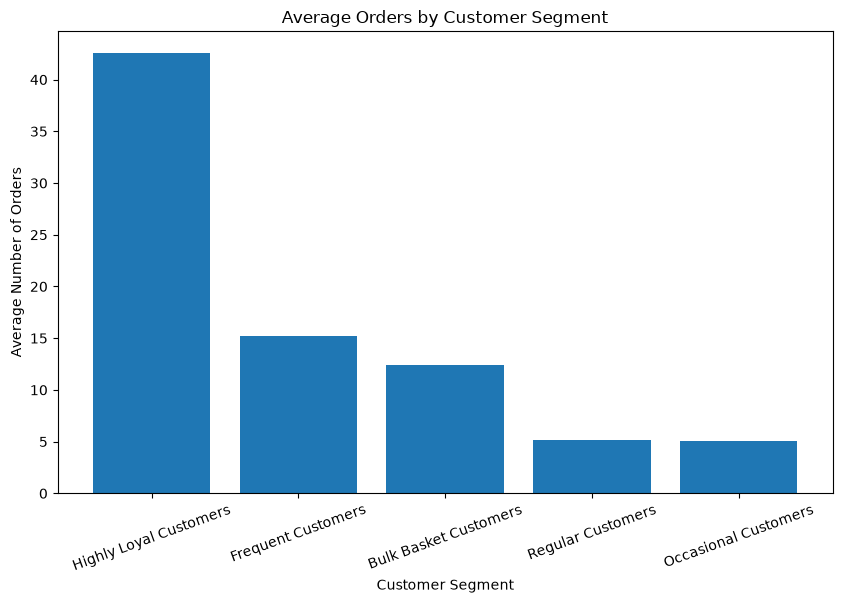

In [53]:
# Visualize the average number of orders by customer segment using a bar chart
segment_orders = (
    cluster_summary["total_orders"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_orders.index,
    segment_orders.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Orders")
plt.title("Average Orders by Customer Segment")

plt.xticks(rotation=20)

plt.show()

In [54]:
# Automatic interpretation of average orders per segment
top_segment = segment_orders.idxmax()
low_segment = segment_orders.idxmin()

print(
    f"{top_segment} have the highest average number of orders "
    f"({segment_orders[top_segment]:.2f}), while {low_segment} have the lowest "
    f"({segment_orders[low_segment]:.2f})."
)

Highly Loyal Customers have the highest average number of orders (42.54), while Occasional Customers have the lowest (5.10).


## **Step 30: Analyze Orders by Day of Week**

> **Assumption:** Instacart does not document which number is which day. We use the most common convention from public analyses of this dataset (0 = Saturday, 1 = Sunday), based on weekend order-volume patterns. The Streamlit app uses the same mapping.

In [55]:
# Analyze the number of prior orders by Day of the Week (DOW)
day_names = {
    0: "Saturday",
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday"
}

DAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday",
             "Thursday", "Friday", "Saturday"]

orders_by_day = (
    orders_prior["order_dow"]
    .value_counts()
    .sort_index()
)

orders_by_day.index = orders_by_day.index.map(day_names)

# Show the days in calendar order
orders_by_day = orders_by_day.reindex(DAY_ORDER)

print("Orders by Day:")
print(orders_by_day)

Orders by Day:
order_dow
Sunday       556705
Monday       441955
Tuesday      412400
Wednesday    401212
Thursday     425982
Friday       418848
Saturday     557772
Name: count, dtype: int64


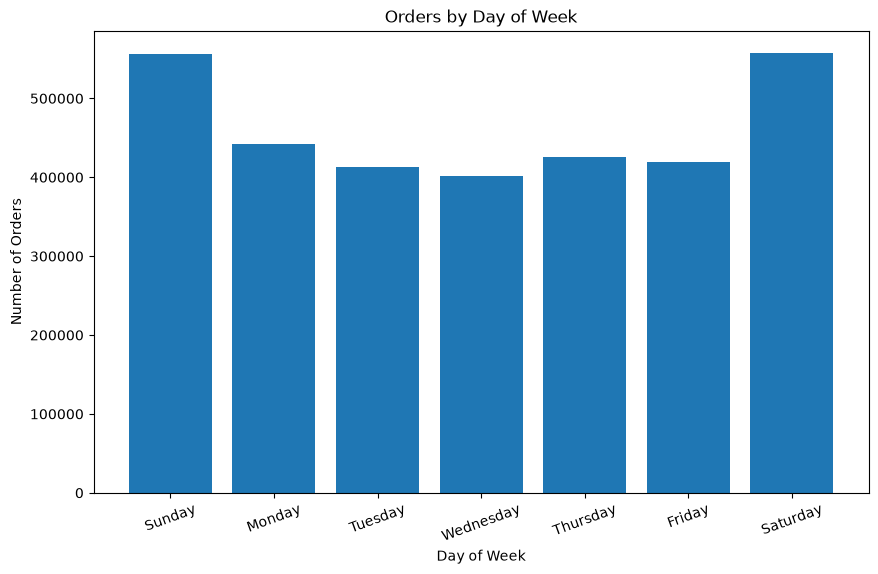

In [56]:
# Visualize Orders by Day
plt.figure(figsize=(10, 6))

plt.bar(
    orders_by_day.index,
    orders_by_day.values
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of Week")

plt.xticks(rotation=20)

plt.show()

## **Step 31: Analyze Orders by Hour**

In [57]:
# Analyze the number of orders by hour of the day
orders_by_hour = (
    orders_prior["order_hour_of_day"]
    .value_counts()
    .sort_index()
)

print("Orders by Hour:")
print(orders_by_hour)

Orders by Hour:
order_hour_of_day
0      21372
1      11596
2       7070
3       5120
4       5175
5       8972
6      28792
7      86656
8     168321
9     243496
10    271885
11    268006
12    256206
13    261174
14    265556
15    266132
16    255949
17    214080
18    170998
19    131620
20     98109
21     73436
22     57540
23     37613
Name: count, dtype: int64


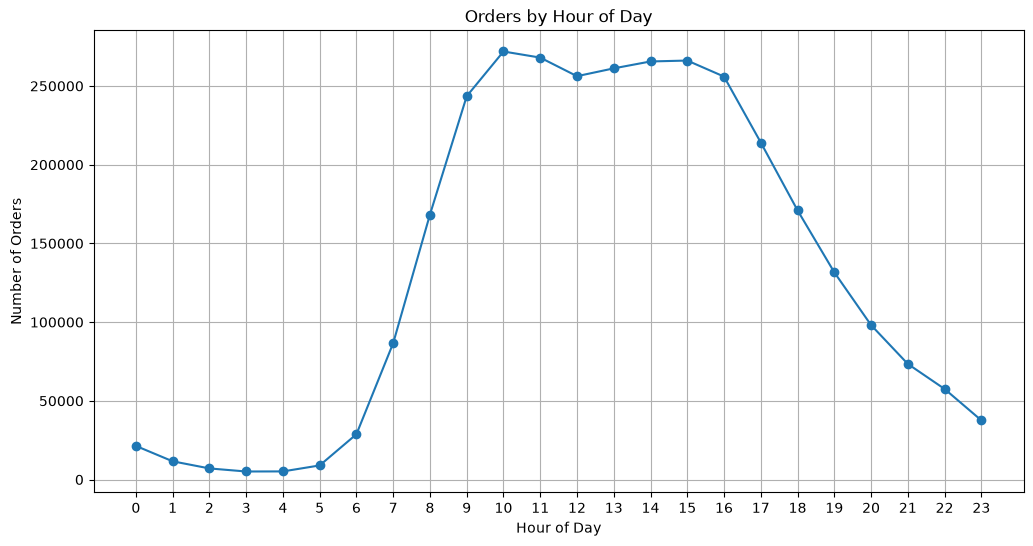

In [58]:
# Visualize Orders by Hour
plt.figure(figsize=(12, 6))

plt.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Hour of Day")

plt.xticks(range(24))

plt.grid(True)

plt.show()

In [59]:
# Find the Peak Ordering Hour
peak_hour = orders_by_hour.idxmax()
peak_orders = orders_by_hour.max()

print("Peak ordering hour:", peak_hour)
print("Number of orders:", peak_orders)

Peak ordering hour: 10
Number of orders: 271885


In [60]:
# Find the Least Ordering Hour
lowest_hour = orders_by_hour.idxmin()
lowest_orders = orders_by_hour.min()

print("Lowest ordering hour:", lowest_hour)
print("Number of orders:", lowest_orders)

Lowest ordering hour: 3
Number of orders: 5120


## **Step 32: Compare Reorder Rate by Customer Segment**

In [61]:
# Compare the reorder rate by customer segment
segment_reorder = (
    cluster_summary["reorder_rate"]
    .sort_values(ascending=False)
)

print("Reorder Rate by Customer Segment:")
print(segment_reorder)

Reorder Rate by Customer Segment:
customer_segment
Highly Loyal Customers    0.69
Frequent Customers        0.51
Bulk Basket Customers     0.48
Occasional Customers      0.28
Regular Customers         0.24
Name: reorder_rate, dtype: float64


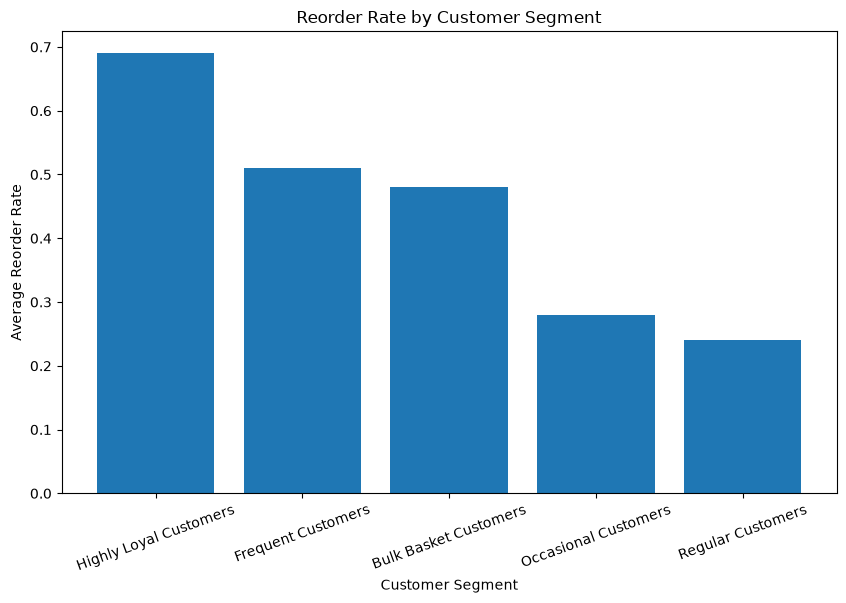

In [62]:
# Visualize the Reorder Rate by Customer Segment using a bar chart

plt.figure(figsize=(10, 6))

plt.bar(
    segment_reorder.index,
    segment_reorder.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Reorder Rate")
plt.title("Reorder Rate by Customer Segment")

plt.xticks(rotation=20)

plt.show()

## **Step 33: Top products per customer segment**

This links the two halves of the project: which products does each segment buy most? `lift_vs_overall` shows how much more (or less) a segment buys a product than customers overall (above 1 means the product is characteristic of that segment).

In [63]:
# Attach each purchase to its customer's cluster (int8 keeps memory small)
cluster_of_user = customer_features.set_index("user_id")["cluster"]

purchases_by_segment = pd.DataFrame({
    "cluster": customer_products["user_id"].map(cluster_of_user).astype("int8"),
    "product_id": customer_products["product_id"]
})

segment_product_counts = (
    purchases_by_segment
    .groupby(["cluster", "product_id"])
    .size()
    .rename("purchase_count")
    .reset_index()
)

segment_product_counts["customer_segment"] = segment_product_counts["cluster"].map(cluster_names)

# Share of the segment's purchases, and how it compares with all customers
segment_total = segment_product_counts.groupby("customer_segment")["purchase_count"].transform("sum")
segment_product_counts["share_pct"] = segment_product_counts["purchase_count"] / segment_total * 100

overall_share = (
    segment_product_counts.groupby("product_id")["purchase_count"].sum()
    / segment_product_counts["purchase_count"].sum()
) * 100

segment_product_counts["lift_vs_overall"] = (
    segment_product_counts["share_pct"]
    / segment_product_counts["product_id"].map(overall_share)
)

segment_product_counts = segment_product_counts.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

segment_top_products = (
    segment_product_counts
    .sort_values(["customer_segment", "purchase_count"], ascending=[True, False])
    .groupby("customer_segment")
    .head(10)
    [["customer_segment", "product_name", "purchase_count", "share_pct", "lift_vs_overall"]]
    .round(2)
    .reset_index(drop=True)
)

print(segment_top_products.groupby("customer_segment").head(3))

          customer_segment            product_name  purchase_count  share_pct  \
0    Bulk Basket Customers                  Banana          112868       1.42   
1    Bulk Basket Customers  Bag of Organic Bananas           70042       0.88   
2    Bulk Basket Customers    Organic Baby Spinach           55292       0.70   
10      Frequent Customers  Bag of Organic Bananas           42428       1.51   
11      Frequent Customers                  Banana           37637       1.34   
12      Frequent Customers    Organic Baby Spinach           21736       0.77   
20  Highly Loyal Customers                  Banana          274857       1.52   
21  Highly Loyal Customers  Bag of Organic Bananas          236455       1.31   
22  Highly Loyal Customers    Organic Strawberries          170154       0.94   
30    Occasional Customers  Bag of Organic Bananas            8335       1.54   
31    Occasional Customers                  Banana            5347       0.99   
32    Occasional Customers  

## **Step 34: Save the important analysis results**

In [64]:
# Save Customer Segmentation
customer_features.to_csv(
    "../processed_data/customer_segments.csv",
    index=False
)

print("Customer segmentation saved successfully.")

Customer segmentation saved successfully.


In [65]:
# Save top products
top_products_df.to_csv(
    "../processed_data/top_products.csv",
    index=False
)

print("Top products saved successfully.")

Top products saved successfully.


In [66]:
# Save Association Rules
rules_to_save = rules.copy()

rules_to_save["antecedents"] = rules_to_save["antecedents"].apply(
    lambda x: ", ".join(x)
)

rules_to_save["consequents"] = rules_to_save["consequents"].apply(
    lambda x: ", ".join(x)
)

rules_to_save.to_csv(
    "../processed_data/association_rules.csv",
    index=False
)

print("Association rules saved successfully.")

Association rules saved successfully.


In [67]:
# Save orders by day and hour (so the app does not need the huge orders.csv)
orders_by_day.rename_axis("day").reset_index(name="orders").to_csv(
    "../processed_data/orders_by_day.csv", index=False
)

orders_by_hour.rename_axis("hour").reset_index(name="orders").to_csv(
    "../processed_data/orders_by_hour.csv", index=False
)

# Save top products per segment
segment_top_products.to_csv(
    "../processed_data/segment_top_products.csv", index=False
)

print("Saved files:", sorted(os.listdir("../processed_data")))

Saved files: ['.DS_Store', 'association_rules.csv', 'customer_segments.csv', 'orders_by_day.csv', 'orders_by_hour.csv', 'segment_top_products.csv', 'top_products.csv']


## **Limitations**

- **Day-of-week labels are an assumption:** the dataset does not document the number-to-day mapping.
- **Rules cover popular products only:** the 150 most purchased products (excluding bananas) on a random sample of 1,000,000 orders, with minimum support 0.5%.
- **`days_since_prior_order` is capped at 30 days** in the source data.
- **Segments come from K-Means with K = 5**, chosen for interpretability; the silhouette score shows the clusters overlap to some degree, which is normal for behavioural data.
- **No time-based validation** of the recommendations was performed (for example, testing rules on the customers' later orders).